# Aufgabe 2

In der zweiten Aufgabe sollten wir aus den Werten die wir gemessen und in 1 dargestellt haben Werte berechnen. Für die Si-Diode sollen wir den Emissionskoeffizienten bestimmen, für die Z-Diode die Z-Spannung, den Gleichstromwiderstand und den differentiellen Widerstand und für die LED sollen wir die Schleusenspannung und daraus die mittlere emittierte Wellenlänge bestimmen.

## Si-Diode

## 1) Si-Diode: Emissionskoeffizient $n$ aus dem linearen Bereich von $\ln(I)$ gegen $U$

### 1.1 Ausgangsgleichung (Shockley)
Für eine Diode gilt im Vorwärtsbetrieb näherungsweise die Shockley-Gleichung:

$$
I(U)=I_S\left(\exp\left(\frac{U}{n\,U_T}\right)-1\right)
$$

mit

$$
U_T=\frac{kT}{e}
$$

**Bedeutung der Größen**
- $I$: Diodenstrom  
- $U$: Diodenspannung  
- $I_S$: Sättigungsstrom  
- $n$: Emissionskoeffizient (Idealitätsfaktor)  
- $U_T$: Thermospannung  
- $k$: Boltzmann-Konstante, $T$: Temperatur, $e$: Elementarladung

### 1.2 Näherung im passenden Messbereich
Im geeigneten Vorwärtsbereich ist der Exponentialterm sehr groß:

$$
\exp\left(\frac{U}{nU_T}\right)\gg 1
$$

Dann kann man „$-1$“ vernachlässigen:

$$
I \approx I_S\exp\left(\frac{U}{nU_T}\right)
$$

### 1.3 Linearisierung durch Logarithmus
Logarithmieren liefert:

$$
\ln(I)\approx \ln(I_S)+\frac{1}{nU_T}U
$$

Das ist die Form einer Geraden

$$
y = a + mU
$$

mit
- $y=\ln(I)$
- $a=\ln(I_S)$
- $m=\frac{1}{nU_T}$

### 1.4 Bestimmung von $n$
Aus der Steigung $m$ folgt:

$$
n=\frac{1}{mU_T}
$$

und mit $U_T=\frac{kT}{e}$:

$$
n=\frac{1}{m}\cdot \frac{e}{kT}
$$

Aus unserem Fit haben wir nun bestimmt (Wir haben $T=293,15K$ gesetzt): 
$$
m \approx 1,8269 \implies n = 2,1668
$$


m  = 1.826883e+01 1/V
n  = 2.1668


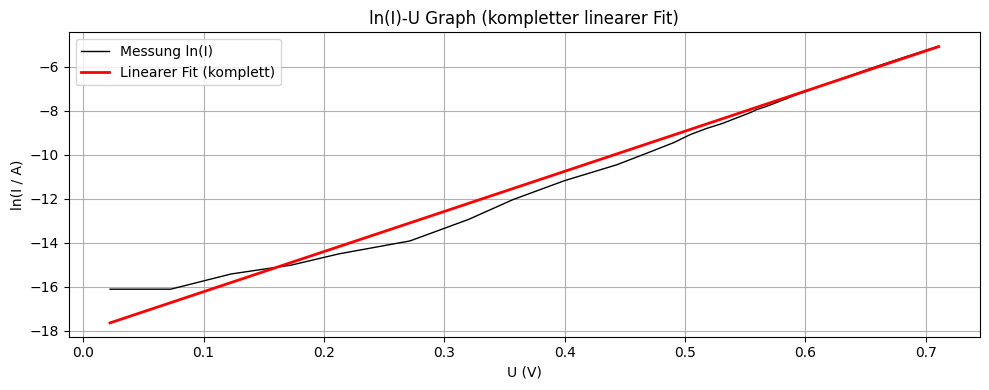

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df1 = pd.read_csv('Messungen/Si_Diode_Aufgabe1.csv')
df1.columns = df1.columns.str.replace('"', '').str.strip()

# Daten (nur Vorwärtsbereich + positive Ströme)
U = df1['U (V)'].to_numpy()
I = df1['I (A)'].to_numpy()
mask = (U > 0) & (I > 0)

U_f = U[mask]
I_f = I[mask]

# sortieren
idx = np.argsort(U_f)
U_f = U_f[idx]
I_f = I_f[idx]

lnI = np.log(I_f)

# ------------------------------------------------------------
# KOMPLETTER FIT in ln(I) = a + m*U  (über alle Vorwärtsdaten)
# ------------------------------------------------------------
m, a = np.polyfit(U_f, lnI, 1)   # ln(I) = m*U + a

# Fitgüte R^2
lnI_hat = m * U_f + a
ss_res = np.sum((lnI - lnI_hat) ** 2)
ss_tot = np.sum((lnI - np.mean(lnI)) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# ------------------------------------------------------------
# n aus der Steigung m
# m = 1/(n*UT)  =>  n = 1/(m*UT)
# ------------------------------------------------------------
T_K = 293.15  # ggf. anpassen
kB = 1.380649e-23
e  = 1.602176634e-19
UT = kB * T_K / e
n = 1.0 / (m * UT)

# Ausgabe
#print("=== Komplett-Fit: ln(I) = a + m*U ===")
print(f"m  = {m:.6e} 1/V")
#print(f"a  = {a:.6f}")
#print(f"R² = {r2:.6f}")
#print(f"UT = {UT*1e3:.3f} mV (bei T = {T_K:.2f} K)")
print(f"n  = {n:.4f}")

# Plot: ln(I) vs U + Fitgerade
plt.figure(figsize=(10, 4))
plt.plot(U_f, lnI, label="Messung ln(I)", color="black", linewidth=1)
plt.plot(U_f, lnI_hat, label="Linearer Fit (komplett)", color="red", linewidth=2)
plt.xlabel("U (V)")
plt.ylabel("ln(I / A)")
plt.title("ln(I)-U Graph (kompletter linearer Fit)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 2) Z-Diode: Zenerspannung $U_Z$, Gleichstromwiderstand $R$ und differentieller Widerstand $r_d$

### 2.1 Zenerspannung $U_Z$ per Extrapolation
Im Durchbruchbereich (Sperrrichtung) ist die Kennlinie oft näherungsweise linear. Man betrachtet daher $U$ als Funktion von $I$:

$$
U(I)\approx aI+b
$$

Die **Extrapolation auf $I=0$** ergibt:

$$
U_Z = b
$$

### 2.2 Widerstände bei $I = 0.2\,I_{Z,\max}$
Zuerst bestimmt man den maximal gemessenen Zenerstrom $I_{Z,\max}$ und dann:

$$
I_\text{target}=0.2\,I_{Z,\max}
$$

**Gleichstromwiderstand**

$$
R=\frac{U}{I}\quad \text{(am Punkt } I=I_\text{target}\text{)}
$$

**Differentieller Widerstand**

$$
r_d=\frac{dU}{dI}
$$

Praktisch bedeutet das:
- $r_d$ ist die **lokale Steigung** der $U(I)$-Kurve in der Nähe von $I_\text{target}$  
- Man bestimmt $r_d$ typischerweise per lokaler linearer Regression um $I_\text{target}$


## LED

## 3) LED: Schleusenspannung $U_S$ und Wellenlänge $\lambda$

### 3.1 Schleusenspannung $U_S$ aus dem linearen Teil von $I(U)$
Im passenden Bereich kann man die LED-Kennlinie näherungsweise als linear ansetzen:

$$
I \approx mU + b
$$

Die Spannung, bei der der lineare Fit $I=0$ ergibt, ist:

$$
U_S = -\frac{b}{m}
$$

### 3.2 Wellenlänge aus $U_S$
Wenn man annimmt, dass die elektrische Energie pro Ladung ungefähr als Photonenergie abgegeben wird:

$$
eU_S = h\nu
$$

und mit

$$
c=\lambda \nu
$$

folgt

$$
\lambda=\frac{hc}{eU_S}
$$

**Ergebnis**
- $U_S$ aus dem linearen Fit bestimmen  
- $\lambda$ mit $\lambda=\frac{hc}{eU_S}$ berechnen  

---

## 4) Typische Fehlerquellen (kurz)
- **Falscher Fit-Bereich**: außerhalb des linearen Abschnitts (Serienwiderstand, Messgrenzen, Erwärmung)  
- **Zu kleine Ströme**: $-1$-Term ist nicht vernachlässigbar, Rauschen dominiert  
- **Zu große Ströme**: Serienwiderstand verzerrt die Exponentialform  
- **Temperatur**: $U_T=\frac{kT}{e}$ hängt direkt von $T$ ab

# Fehlerbetrachtung
